In [3]:
# Installation
install.packages("tidyverse")
install.packages("scales")
library(tidyverse)
library(scales)

# Initialization
options(repr.plot.width = 9, repr.plot.height = 6)

Installing package into 'C:/Users/marsh/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'tidyverse' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\marsh\AppData\Local\Temp\RtmpO4vrFR\downloaded_packages


Installing package into 'C:/Users/marsh/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'scales' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\marsh\AppData\Local\Temp\RtmpO4vrFR\downloaded_packages


Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'tidyr' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
Warning message:
"package 'forcats' was built under R version 4.4.3"
Warning message:
"package 'lubridate' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package

Importing data

In [55]:
# Import and wrangle data sources
hypixel_items <- read_tsv("data_sources/hypixel/data/items.tsv") |>
    select(id, category)
fandom_items <- read_tsv("data_sources/fandom/data/pages_table.tsv") |>
    select(id, title, buy, upgrades_from, lower_tier) |>
    mutate(id = str_to_upper(id)) # fandom has some ids in lower case
coflnet_prices <- read_tsv("data_sources/coflnet/data/prices.tsv")
magic_power <- read_tsv("data_sources/manual/data/magic_power.tsv")

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 5380 Columns: 67
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (21): material, name, category, tier, id, salvages, description, item_mo...
dbl  (6): durability, npc_sell_price, generator_tier, gear_score, motes_sell...
lgl (40): skin, rarity_salvageable, stats, unstackable, dungeon_item_convers...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 4330 Columns: 1306
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (468): id, location, npcs, resources, title, aka, type, image, slot, rar...
dbl (

In [57]:
# downgrades
fandom_ids <- fandom_items |>
    select(downgrade_id = id, title)

items <- hypixel_items |>
    left_join(fandom_items, by = "id") |>
    mutate(downgrade = coalesce(upgrades_from, lower_tier)) |>
    left_join(fandom_ids, by = c("downgrade" = "title"))

# prices
items <- items |>
    mutate(npc_buy_price = str_extract(buy, "^[0-9,]+(?= Coins$)"),
        npc_buy_price = as.numeric(str_remove_all(npc_buy_price, ",")),) |>
    left_join(coflnet_prices, by = "id") |>
    mutate(price = coalesce(npc_buy_price, price, 0))

# cleanup
items <- items |>
    select(id, category, price, downgrade_id)

accessories <- items |>
    filter(category == "ACCESSORY")
print(accessories, n = Inf)

# A tibble: 397 × 4
    id                               category       price downgrade_id          
    <chr>                            <chr>          <dbl> <chr>                 
  1 TARANTULA_RING                   ACCESSORY   62000000 TARANTULA_TALISMAN    
  2 ARCHAEOLOGIST_COMPASS            ACCESSORY          0 NA                    
  3 ANITA_TALISMAN                   ACCESSORY    1400000 NA                    
  4 PESTHUNTER_RING                  ACCESSORY     598000 PESTHUNTER_BADGE      
  5 ANITA_ARTIFACT                   ACCESSORY   11850000 ANITA_RING            
  6 ANITA_RING                       ACCESSORY    4800000 ANITA_TALISMAN        
  7 PESTHUNTER_BADGE                 ACCESSORY     120000 NA                    
  8 PESTHUNTER_ARTIFACT              ACCESSORY    1199998 PESTHUNTER_RING       
  9 PARTY_HAT_SLOTH                  ACCESSORY    3940000 NA                    
 10 PARTY_HAT_CRAB_ANIMATED          ACCESSORY   10000000 NA                    
 11 PART

id,tier,price,mp,child,child_price,child_mp,effective_price,effective_mp
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TARANTULA_RING,LEGENDARY,62000000,16,TARANTULA_TALISMAN,170000,12,61830000,4
ARCHAEOLOGIST_COMPASS,COMMON,0,3,NA,NA,NA,0,3
ANITA_TALISMAN,COMMON,1990000,3,NA,NA,NA,1990000,3
PESTHUNTER_RING,RARE,600000,8,NA,NA,NA,600000,8
ANITA_ARTIFACT,RARE,12900000,8,NA,NA,NA,12900000,8
ANITA_RING,UNCOMMON,5400000,5,NA,NA,NA,5400000,5
PESTHUNTER_BADGE,UNCOMMON,230000,5,NA,NA,NA,230000,5
PESTHUNTER_ARTIFACT,EPIC,1499998,12,NA,NA,NA,1499998,12
PARTY_HAT_SLOTH,SPECIAL,3734447,3,NA,NA,NA,3734447,3


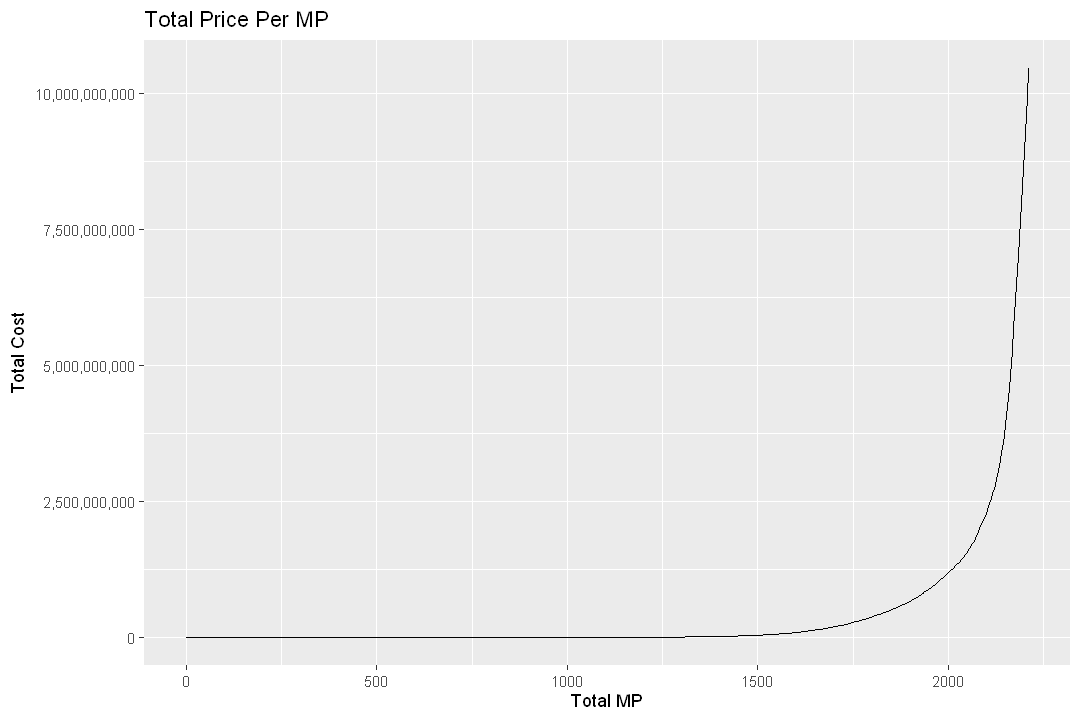

In [62]:
accessories_effective <- accessories |>
    left_join(accessory_upgrades, by = c("id" = "parent")) |>
    left_join(accessories |> select(child_id = id, child_price = price), by = c("child" = "child_id")) |>
    left_join(accessories |> select(child_id = id, child_mp = mp), by = c("child" = "child_id")) |>
    mutate(effective_price = price - coalesce(child_price, 0)) |>
    mutate(effective_mp = mp - coalesce(child_mp, 0))
accessories_effective

coins_per_mp <- accessories_effective |>
    mutate(coins_per_mp = effective_price / effective_mp) |>
    arrange(coins_per_mp) |>
    mutate(total_coins = cumsum(effective_price)) |>
    mutate(total_mp = cumsum(effective_mp))

coins_per_mp_graph <- coins_per_mp |>
    ggplot(aes(x = total_mp, y = total_coins)) +
    geom_line() +
    scale_y_continuous(labels = comma) +
    labs(title = "Total Price Per MP") +
    xlab("Total MP") +
    ylab("Total Cost")
coins_per_mp_graph

In [33]:
fandom_data <- read_tsv("data_sources/fandom/data/pages_table.tsv") |>
    select(id, title, type, upgrades_from, buy)

real_accessories <- accessories |>
    left_join(fandom_data, by = c("id" = "id")) |>
    mutate(buy_price = str_extract(buy, "^[0-9,]+(?= Coins$)"),
        buy_price = as.numeric(str_remove_all(buy_price, ",")),) |>
    mutate(real_price = coalesce(buy_price, price, 0)) |>
    filter(id == "SCAVENGER_TALISMAN")
real_accessories

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 3116 Columns: 1199
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (483): type, image, slot, id, rarity, source, upgradeable, salable, auct...
dbl (134): museum_xp, x, z, base_value, fishing_speed, rift_time, mining_spe...
num   (4): y, defense2, defense3, defense4
lgl (578): fishing_wisdom, farming_wisdom, item, head_int, helmet_ad, leggin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,tier,price,mp,title,type,upgrades_from,buy,buy_price,real_price
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
SCAVENGER_TALISMAN,NA,0,NA,Scavenger Talisman,NA,NA,"10,000 Coins",10000,10000
